<a href="https://colab.research.google.com/github/pachterlab/tcga-ct-processing-protocol/blob/main/tcga_ct_processing_protocol.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
try:
    import tcga_radiogenomics
except ImportError:
    print("tcga_radiogenomics not found, installing...")
    # !pip install -q git+https://github.com/pachterlab/tcga-radiogenomics.git

# Processing TCIA CT data from TCGA for radiogenomics analysis

In [ ]:
import os
import sys
import shutil
import subprocess
import pydicom
import pandas as pd
from tqdm import tqdm
import yaml
from IPython.display import Image, display
from tcga_radiogenomics import utils

from IPython.core.magic import register_cell_magic
from IPython import get_ipython

@register_cell_magic
def skip_if(line, cell):
    if eval(line):
        return
    get_ipython().run_cell(cell)

base_directory = os.path.dirname(os.path.abspath(""))

# import importlib
# import tcga_radiogenomics.utils as utils
# importlib.reload(utils)

# Define hyperparameters

In [3]:
dataset = "tcga-kirc"
data_dir = "/mnt/gpussd2/jrich/data/radiogenomics/tcga-kirc/imaging"  #!!! "/home/jrich/data/radiogenomics_mar26/tcga-kirc/imaging"  # os.path.join(base_directory, "data", "radiogenomics", dataset, "imaging")
nbia_data_retriever = "/mnt/gpussd2/jrich/opt/nbia/opt/nbia-data-retriever/bin/nbia-data-retriever"  # path to nbia-data-retriever executable
num_cases = None  # number of cases to keep - set to None for all cases
using_usc_data = True
image_dimensionality = "3D"  # "2D" or "3D"
do_radiomics = False

resampledPixelSpacing = [1, 1, 1] if image_dimensionality == "3D" else [1, 1]
pyradiomics_param = {
    "imageType": {
        "Original": {}    
    },
    "setting": {
        "binWidth": 25,
        "resampledPixelSpacing": resampledPixelSpacing,
        "interpolator": "sitkBSpline",
        "normalize": False,
        "padDistance": 5
    }
}

# Data download

In [4]:
tcia_dataset_to_info = {
    "tcga-kirc": {
        "manifest_url": "https://www.cancerimagingarchive.net/wp-content/uploads/TCIA_TCGA-KIRC_09-16-2015.tcia",
        "metadata_url": "https://www.cancerimagingarchive.net/wp-content/uploads/TCIA_TCGA-KIRC_09-16-2015-nbia-digest.xlsx",
        "totalsegmentator_organs": ["kidney_left", "kidney_right"]
    },
    "tcga-lihc": {
        "manifest_url": "https://www.cancerimagingarchive.net/wp-content/uploads/TCIA_TCGA-LIHC_09-16-2015.tcia",
        "metadata_url": "https://www.cancerimagingarchive.net/wp-content/uploads/doiJNLP-TCGA-LIHC-01-30-2017-nbia-digest.xlsx",
        "totalsegmentator_organs": ["liver"]
    },
    # add more datasets here as needed
}

if dataset not in tcia_dataset_to_info:
    raise ValueError(f"Dataset {dataset} not recognized. Please add it to tcia_dataset_to_info.")

## Metadata

In [ ]:
%%skip_if using_usc_data

metadata_name = f"metadata_{num_cases}.csv" if num_cases is not None else "metadata.csv"
imaging_metadata_csv = os.path.join(data_dir, metadata_name)

if not os.path.exists(imaging_metadata_csv):
    imaging_metadata_csv_dir = os.path.dirname(imaging_metadata_csv) if os.path.dirname(imaging_metadata_csv) != "" else "."
    additional_metadata_file_name = tcia_dataset_to_info[dataset]["metadata_url"].split("/")[-1]
    additional_metadata_xlsx = os.path.join(imaging_metadata_csv_dir, additional_metadata_file_name)

    os.makedirs(imaging_metadata_csv_dir, exist_ok=True)
    if not os.path.exists(additional_metadata_xlsx):
        subprocess.run(["wget", "-O", additional_metadata_xlsx, tcia_dataset_to_info[dataset]["metadata_url"]], check=True)
    
    # add short patient ID
    imaging_metadata_df = pd.read_excel(additional_metadata_xlsx)
    imaging_metadata_df.insert(0, "caseID", [f"case_{i:05d}" for i in range(len(imaging_metadata_df))])
    
    # change column names to match old format
    col_renames = {
        "Series Instance UID": "Series UID",
        "Study Instance UID": "Study UID",
        "Patient ID": "Subject ID",
        "Image Count": "Number of Images Original",
    }
    imaging_metadata_df.rename(columns=col_renames, inplace=True)
    imaging_metadata_df.to_csv(imaging_metadata_csv, index=False)

metadata_df = pd.read_csv(imaging_metadata_csv)

In [ ]:
%%skip_if using_usc_data

print(f"Number of imaging cases in metadata: {len(metadata_df)}")
metadata_df.head()

In [ ]:
%%skip_if using_usc_data

metadata_df["ParsedRegion"] = metadata_df["Study Description"].apply(utils.categorize_region_tcga)
if dataset == "tcga-kirc":
    metadata_df["Phase"] = metadata_df["Series Description"].apply(utils.categorize_phase)
utils.print_tcia_info(metadata_df, project=dataset)

## Imaging data

In [ ]:
%%skip_if using_usc_data

manifest_url = tcia_dataset_to_info[dataset]["manifest_url"]
manifest_file_name = manifest_url.split("/")[-1]
manifest_file_path = os.path.join(data_dir, manifest_file_name)

if not os.path.exists(manifest_file_path):
    subprocess.run(f"wget {manifest_url} -P {data_dir}", shell=True, check=True)
if num_cases is not None:
    manifest_file_path_subset_cases = manifest_file_path.replace(".tcia", f"_subset_{num_cases}.tcia")
    if not os.path.exists(manifest_file_path_subset_cases):
        with open(manifest_file_path, "r") as f_in, open(manifest_file_path_subset_cases, "w") as f_out:
            num_lines = num_cases + 6  # 6 header lines in manifest file
            for i, line in enumerate(f_in):
                if i >= num_lines:
                    break
                f_out.write(line)
    manifest_file_path = manifest_file_path_subset_cases
    manifest_file_name = manifest_file_path.split("/")[-1]
    series_uids = utils.get_series_uids_from_manifest(manifest_file_path)
    metadata_df = metadata_df[metadata_df["Series UID"].isin(series_uids)]

metadata_df.head()

In [ ]:
%%skip_if using_usc_data

image_dir = os.path.join(data_dir, manifest_file_name.split(".")[0])
if not os.path.exists(image_dir) or len(os.listdir(image_dir)) == 0:
    if shutil.which(nbia_data_retriever) is None:
        sys.exit(f"Error: {nbia_data_retriever} not found in PATH. Please install or add it to PATH.")

    nbia_command = f"echo Y | {nbia_data_retriever} --cli {manifest_file_path} -d {data_dir} -v -f"
    print(f"Running NBIA Data Retriever with command:\n{nbia_command}")
    subprocess.run(nbia_command, shell=True, check=True)
print(f"Downloaded images to: {image_dir}")

### View imaging data

In [ ]:
%%skip_if using_usc_data

!tree {image_dir} -P "1-1.dcm|1-01.dcm|01-01.dcm|1-001.dcm"

In [ ]:
%%skip_if using_usc_data

image_subdir = os.path.join(image_dir, os.listdir(image_dir)[0])

sample_dcm_file = subprocess.check_output(
    f'find {image_subdir} -type f -name "*.dcm" | sort | head -n 1',
    shell=True
).decode().strip()
sample_dcm_dir = os.path.dirname(sample_dcm_file)

dcm = pydicom.dcmread(sample_dcm_file, stop_before_pixels=True)
uid = dcm.SeriesInstanceUID

print(sample_dcm_file)
print(uid)

In [ ]:
%%skip_if using_usc_data

utils.view_dicom(sample_dcm_file)

In [ ]:
%%skip_if using_usc_data

utils.view_dicom(sample_dcm_dir)

### Add acquisition time data for kidney

In [ ]:
# if dataset == "tcga-kirc":
#     metadata_df = utils.update_phase_column_with_acquisition_time(metadata_df, image_dir)
#     metadata_df.head()

# Data filtering

In [ ]:
%%skip_if using_usc_data

metadata_df = utils.add_viable_info(image_subdir, metadata_df, min_files=5, max_thickness_mm=10, include_kernel_keywords=True, out=imaging_metadata_csv, overwrite=True)
metadata_df[["caseID", "Series UID", "is_viable", "viable_reason"]].head()

In [ ]:
%%skip_if using_usc_data

metadata_df = metadata_df[metadata_df["is_viable"]]
metadata_df = metadata_df[metadata_df["Modality"] == "CT"]
utils.print_tcia_info(metadata_df, project=dataset)
metadata_df.head()

# DICOM to NIfTI

In [ ]:
%%skip_if using_usc_data

image_filename = "imaging.nii.gz"
tumor_mask_filename = None
nifti_dir_name = f"nifti_{num_cases}" if num_cases is not None else "nifti"
nifti_dir = os.path.join(data_dir, nifti_dir_name)

if not os.path.exists(nifti_dir) or len(os.listdir(nifti_dir)) == 0:
    utils.convert_dcm_to_nii_and_organize(image_dir, metadata_df, nifti_dir, segimage2itkimage_conda=False)

In [ ]:
%%skip_if using_usc_data

# filter out 4D volumes and niis with big max zoom (sometimes some series will have an axial localizer but an otherwise coronal/sagittal series - we want to exclude these)
metadata_df = utils.check_and_delete_bad_niftis(metadata_df, nifti_dir, image_filename=image_filename, is_4d=True, max_zoom_maximum=20)
utils.print_tcia_info(metadata_df, project=dataset)
metadata_df.head()

In [5]:
if using_usc_data and dataset == "tcga-kirc":
    metadata_name = f"metadata_usc_{num_cases}.csv" if num_cases is not None else "metadata_usc.csv"
    imaging_metadata_csv = os.path.join(data_dir, metadata_name)
    
    nifti_dir_name = f"nifti_usc_{num_cases}" if num_cases is not None else "nifti_usc"
    nifti_dir = os.path.join(data_dir, nifti_dir_name)
    
    image_filename = "0502_VENOUS.nii"
    tumor_mask_filename = "segmentation_tumor.nii.gz"

    if not os.path.exists(nifti_dir) or len(os.listdir(nifti_dir)) == 0:
        tcga_kirc_images_dir = utils.download_usc_tcga_kirc_data(data_dir, imaging_metadata_csv=imaging_metadata_csv, num_cases=num_cases, dst_dir_name=nifti_dir_name)

    metadata_df = pd.read_csv(imaging_metadata_csv)

In [6]:
!tree -L 2 {nifti_dir}

/mnt/gpussd2/jrich/data/radiogenomics/tcga-kirc/imaging/nifti_usc
├── TCGA-B0-4698
│   ├── 0502_VENOUS.nii
│   ├── 0502_VENOUS_oriented.nii.gz
│   ├── ROI_602_Tumor_a.nii
│   ├── segmentation.nii.gz
│   ├── segmentation_organs.nii.gz
│   ├── segmentation_tumor.nii.gz
│   ├── segmentation_tumor_oriented.nii.gz
│   └── totalsegmentator
├── TCGA-B0-4713
│   ├── 0502_VENOUS.nii
│   ├── 0502_VENOUS_oriented.nii.gz
│   ├── ROI_602_Tumor_a.nii
│   ├── segmentation.nii.gz
│   ├── segmentation_organs.nii.gz
│   ├── segmentation_tumor.nii.gz
│   ├── segmentation_tumor_oriented.nii.gz
│   └── totalsegmentator
├── TCGA-B0-4821
│   ├── 0502_VENOUS.nii
│   ├── 0502_VENOUS_oriented.nii.gz
│   ├── ROI_602_Tumor_a.nii
│   ├── segmentation.nii.gz
│   ├── segmentation_organs.nii.gz
│   ├── segmentation_tumor.nii.gz
│   ├── segmentation_tumor_oriented.nii.gz
│   └── totalsegmentator
├── TCGA-B0-4833
│   ├── 0502_VENOUS.nii
│   ├── 0502_VENOUS_oriented.nii.gz
│   ├── ROI_602_Tumor_a.nii
│   ├── segmentatio

In [6]:
caseid_for_sample_uid = metadata_df["caseID"].iloc[0]  # metadata_df[metadata_df["Series UID"] == uid].iloc[0]["caseID"]
sample_nii_dir = os.path.join(nifti_dir, caseid_for_sample_uid)
sample_nii_file = os.path.join(sample_nii_dir, image_filename)

print(sample_nii_file)

/mnt/gpussd2/jrich/data/radiogenomics/tcga-kirc/imaging/nifti_usc/TCGA-CJ-4892/0502_VENOUS.nii


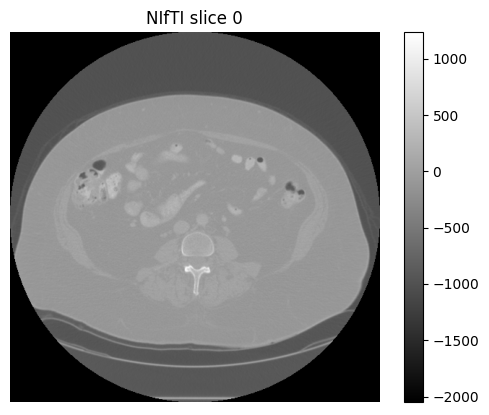

In [8]:
utils.view_nifti(sample_nii_file, z=0)

In [9]:
utils.view_nifti(sample_nii_file)

interactive(children=(IntSlider(value=98, description='z', max=196), Output()), _dom_classes=('widget-interact…

# Orientation

In [7]:
orient = True

oriented_image_files, final_image_files, final_mask_files = [], [], []
for caseID in tqdm(sorted(os.listdir(nifti_dir)), desc="Processing images"):
    case_dir = os.path.join(nifti_dir, caseID)
    image_file = os.path.join(case_dir, image_filename)
    mask_file = os.path.join(case_dir, tumor_mask_filename) if tumor_mask_filename else ""
    if not os.path.exists(image_file):
        print(f"Image file not found for caseID {caseID} at {image_file}. Skipping.")
        continue

    if orient:
        image_file = utils.set_canonical_orientation(image_file, out=True)
        oriented_image_files.append(image_file)
        print(f"Set canonical orientation for image file for caseID {caseID} at {image_file}.")
        if os.path.exists(mask_file):
            mask_file = utils.set_canonical_orientation(mask_file, out=True)
    
    final_image_files.append(image_file)
    final_mask_files.append(mask_file)

image_filename_set = set([os.path.basename(f) for f in final_image_files])
assert len(image_filename_set) == 1, f"Expected all image files to have the same filename, but found: {image_filename_set}"
image_filename = list(image_filename_set)[0]
tumor_mask_filename = os.path.basename(final_mask_files[0]) if final_mask_files else ""

Processing images: 100%|██████████| 190/190 [00:00<00:00, 26549.77it/s]

Set canonical orientation for image file for caseID TCGA-B0-4698 at /mnt/gpussd2/jrich/data/radiogenomics/tcga-kirc/imaging/nifti_usc/TCGA-B0-4698/0502_VENOUS_oriented.nii.gz.
Set canonical orientation for image file for caseID TCGA-B0-4713 at /mnt/gpussd2/jrich/data/radiogenomics/tcga-kirc/imaging/nifti_usc/TCGA-B0-4713/0502_VENOUS_oriented.nii.gz.
Set canonical orientation for image file for caseID TCGA-B0-4821 at /mnt/gpussd2/jrich/data/radiogenomics/tcga-kirc/imaging/nifti_usc/TCGA-B0-4821/0502_VENOUS_oriented.nii.gz.
Set canonical orientation for image file for caseID TCGA-B0-4833 at /mnt/gpussd2/jrich/data/radiogenomics/tcga-kirc/imaging/nifti_usc/TCGA-B0-4833/0502_VENOUS_oriented.nii.gz.
Set canonical orientation for image file for caseID TCGA-B0-4839 at /mnt/gpussd2/jrich/data/radiogenomics/tcga-kirc/imaging/nifti_usc/TCGA-B0-4839/0502_VENOUS_oriented.nii.gz.
Set canonical orientation for image file for caseID TCGA-B0-4843 at /mnt/gpussd2/jrich/data/radiogenomics/tcga-kirc/imag

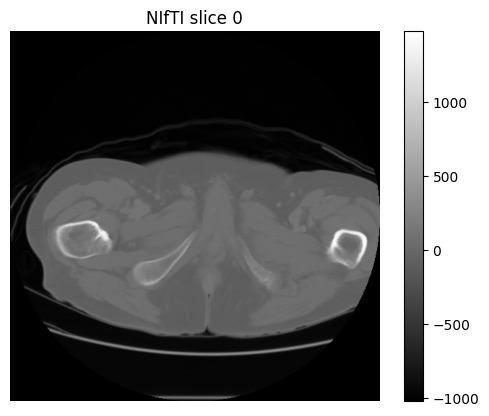

In [11]:
if oriented_image_files:
    utils.view_nifti(oriented_image_files[0], z=0)

# Organ and tumor segmentation

## Tumor segmentation

In [12]:
#!!! fill this in
# tumor_mask_filename = "segmentation_tumor.nii.gz"

## Organ segmentation with TotalSegmentator

In [ ]:
combined_organ_mask_filename = "segmentation_organs.nii.gz"
mask_filename = "segmentation.nii.gz"  # tumor + organs

utils.run_totalsegmentator(nifti_dir, selected_segmentations=tcia_dataset_to_info[dataset]["totalsegmentator_organs"], metadata_csv=metadata_df, metadata_csv_out=imaging_metadata_csv, remove_small_blobs=True, fill_holes=True, morphological_closing=True, image_filename=image_filename, tumor_mask_filename=tumor_mask_filename, combined_organ_mask_filename=combined_organ_mask_filename, mask_filename_out=mask_filename, visualize=False)
metadata_df = pd.read_csv(imaging_metadata_csv)

INFO:tcga_radiogenomics.utils:TotalSegmentator has already been run for caseID TCGA-B0-4698.
INFO:tcga_radiogenomics.utils:Combining full organ segmentations for caseID TCGA-B0-4698...
INFO:tcga_radiogenomics.utils:Applying hole filling and morphological closing to kidney_left segmentation for caseID TCGA-B0-4698...


INFO:tcga_radiogenomics.utils:Applying hole filling and morphological closing to kidney_right segmentation for caseID TCGA-B0-4698...
INFO:tcga_radiogenomics.utils:Combining organ and tumor segmentations for caseID TCGA-B0-4698...
INFO:tcga_radiogenomics.utils:TotalSegmentator has already been run for caseID TCGA-B0-4713.
INFO:tcga_radiogenomics.utils:Combining full organ segmentations for caseID TCGA-B0-4713...
INFO:tcga_radiogenomics.utils:Applying hole filling and morphological closing to kidney_left segmentation for caseID TCGA-B0-4713...
INFO:tcga_radiogenomics.utils:Applying hole filling and morphological closing to kidney_right segmentation for caseID TCGA-B0-4713...
INFO:tcga_radiogenomics.utils:Combining organ and tumor segmentations for caseID TCGA-B0-4713...
INFO:tcga_radiogenomics.utils:TotalSegmentator has already been run for caseID TCGA-B0-4821.
INFO:tcga_radiogenomics.utils:Combining full organ segmentations for caseID TCGA-B0-4821...
INFO:tcga_radiogenomics.utils:Apply

In [ ]:
sample_nii_mask_file = os.path.join(sample_nii_dir, mask_filename)
utils.view_nifti(sample_nii_mask_file)

interactive(children=(IntSlider(value=98, description='z', max=196), Output()), _dom_classes=('widget-interact…

In [16]:
sample_totalsegmentator_visualization_dir = os.path.join(sample_nii_dir, "totalsegmentator", "visualization")
if os.path.exists(sample_totalsegmentator_visualization_dir):
    sample_totalsegmentator_visualization_file = None
    for file in os.listdir(sample_totalsegmentator_visualization_dir):
        if file.endswith("_K.png"):
            sample_totalsegmentator_visualization_file = os.path.join(sample_totalsegmentator_visualization_dir, file)
            break
    if sample_totalsegmentator_visualization_file:
        display(Image(filename=sample_totalsegmentator_visualization_file))
    else:
        print(f"No visualization file with organ found in {sample_totalsegmentator_visualization_dir}")

# Clipping, resampling, and intensity normalization

In [ ]:
clip_min, clip_max = -200, 300
resample = True if not do_radiomics else False  # handled inside params yaml file for radiomics
normalize = True if not do_radiomics else False  # handled inside params yaml file for radiomics
normalization_method = "volume"

clipped_image_files, resampled_image_files, resampled_mask_files, normalized_image_files, final_image_files, final_mask_files = [], [], [], [], [], []
for caseID in tqdm(sorted(os.listdir(nifti_dir)), desc="Processing images"):
    case_dir = os.path.join(nifti_dir, caseID)
    image_file = os.path.join(case_dir, image_filename)
    mask_file = os.path.join(case_dir, mask_filename) if mask_filename else ""
    if not os.path.exists(image_file):
        print(f"Image file not found for caseID {caseID} at {image_file}. Skipping.")
        continue
    
    if clip_min is not None or clip_max is not None:  # eg (-200, 300) for soft tissue window - done in training loop
        print(f"Clipping intensity range for image file for caseID {caseID} at {image_file} with clip_min={clip_min}, clip_max={clip_max}.")
        image_file = utils.clip_intensity_range(image_file, clip_min=clip_min, clip_max=clip_max, out=True)
        clipped_image_files.append(image_file)

    if resample:
        image_file = utils.resample_image(image_file, target_spacing=(0.8, 0.8, 3.0), is_label=False, out=True)
        resampled_image_files.append(image_file)
        print(f"Resampled image file for caseID {caseID} at {image_file}.")
        if os.path.exists(mask_file):
            mask_file = utils.resample_image(mask_file, target_spacing=(0.8, 0.8, 3.0), is_label=True, out=True)
            resampled_mask_files.append(mask_file)

    if normalize:  # done in training loop
        print(f"Normalizing intensity for image file for caseID {caseID} at {image_file}.")
        image_file = utils.normalize_intensity(image_file, out=True)
        normalized_image_files.append(image_file)

    final_image_files.append(image_file)
    if mask_filename:
        final_mask_files.append(mask_file)

image_filename_set = set([os.path.basename(f) for f in final_image_files])
assert len(image_filename_set) == 1, f"Expected all image files to have the same filename, but found: {image_filename_set}"
image_filename = list(image_filename_set)[0]

if mask_filename:
    mask_filename_set = set([os.path.basename(f) for f in final_mask_files if f])  # filter out empty mask files
    assert len(mask_filename_set) <= 1, f"Expected all mask files to have the same filename, but found: {mask_filename_set}"
    mask_filename = list(mask_filename_set)[0] if mask_filename_set else ""

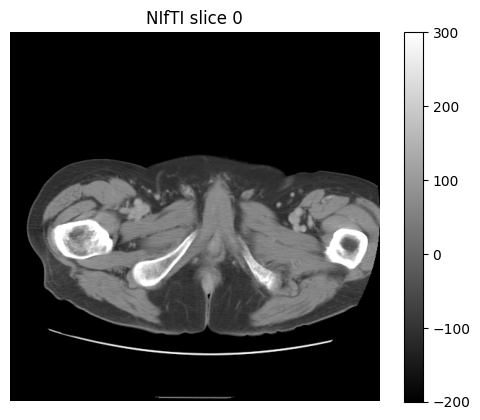

In [27]:
if clipped_image_files:
    utils.view_nifti(clipped_image_files[0], z=0)

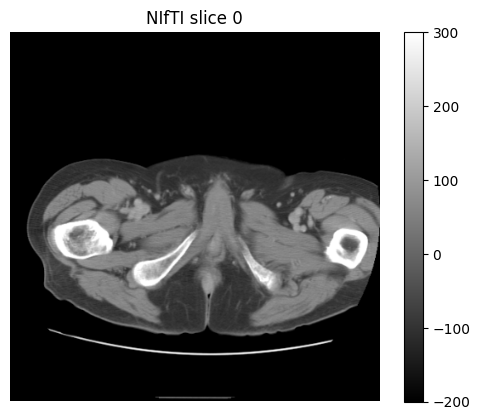

In [28]:
if resampled_image_files:
    utils.view_nifti(resampled_image_files[0], z=0)

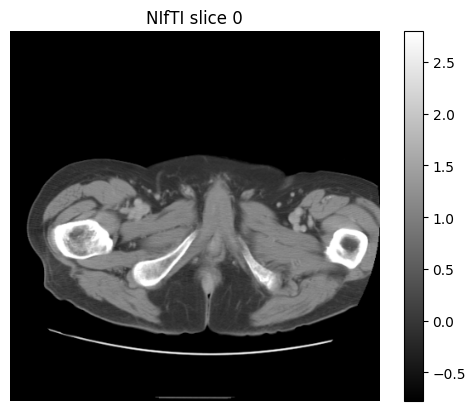

In [29]:
if normalized_image_files:
    utils.view_nifti(normalized_image_files[0], z=0)

In [36]:
if not do_radiomics:
    final_image_files_stats = utils.check_dataset_intensity_consistency(final_image_files)
    print(final_image_files_stats[0])

INFO:tcga_radiogenomics.utils:Intensity QC PASSED.


{'path': '/mnt/gpussd2/jrich/data/radiogenomics/tcga-kirc/imaging/nifti_usc/TCGA-B0-4698/0502_VENOUS_oriented_clipped_resampled_normalized.nii.gz', 'min': np.float64(-0.7781372666358948), 'max': np.float64(2.7960309982299805), 'mean': np.float64(6.370144044218827e-07), 'std': np.float64(1.0000024427735787)}


# Region selection

## 3D

INFO:tcga_radiogenomics.utils:Using fixed z range (95th percentile): 46
INFO:tcga_radiogenomics.utils:Saved histogram to /mnt/gpussd2/jrich/data/radiogenomics/tcga-kirc/imaging/visualization/organ_z_extent_histogram.png


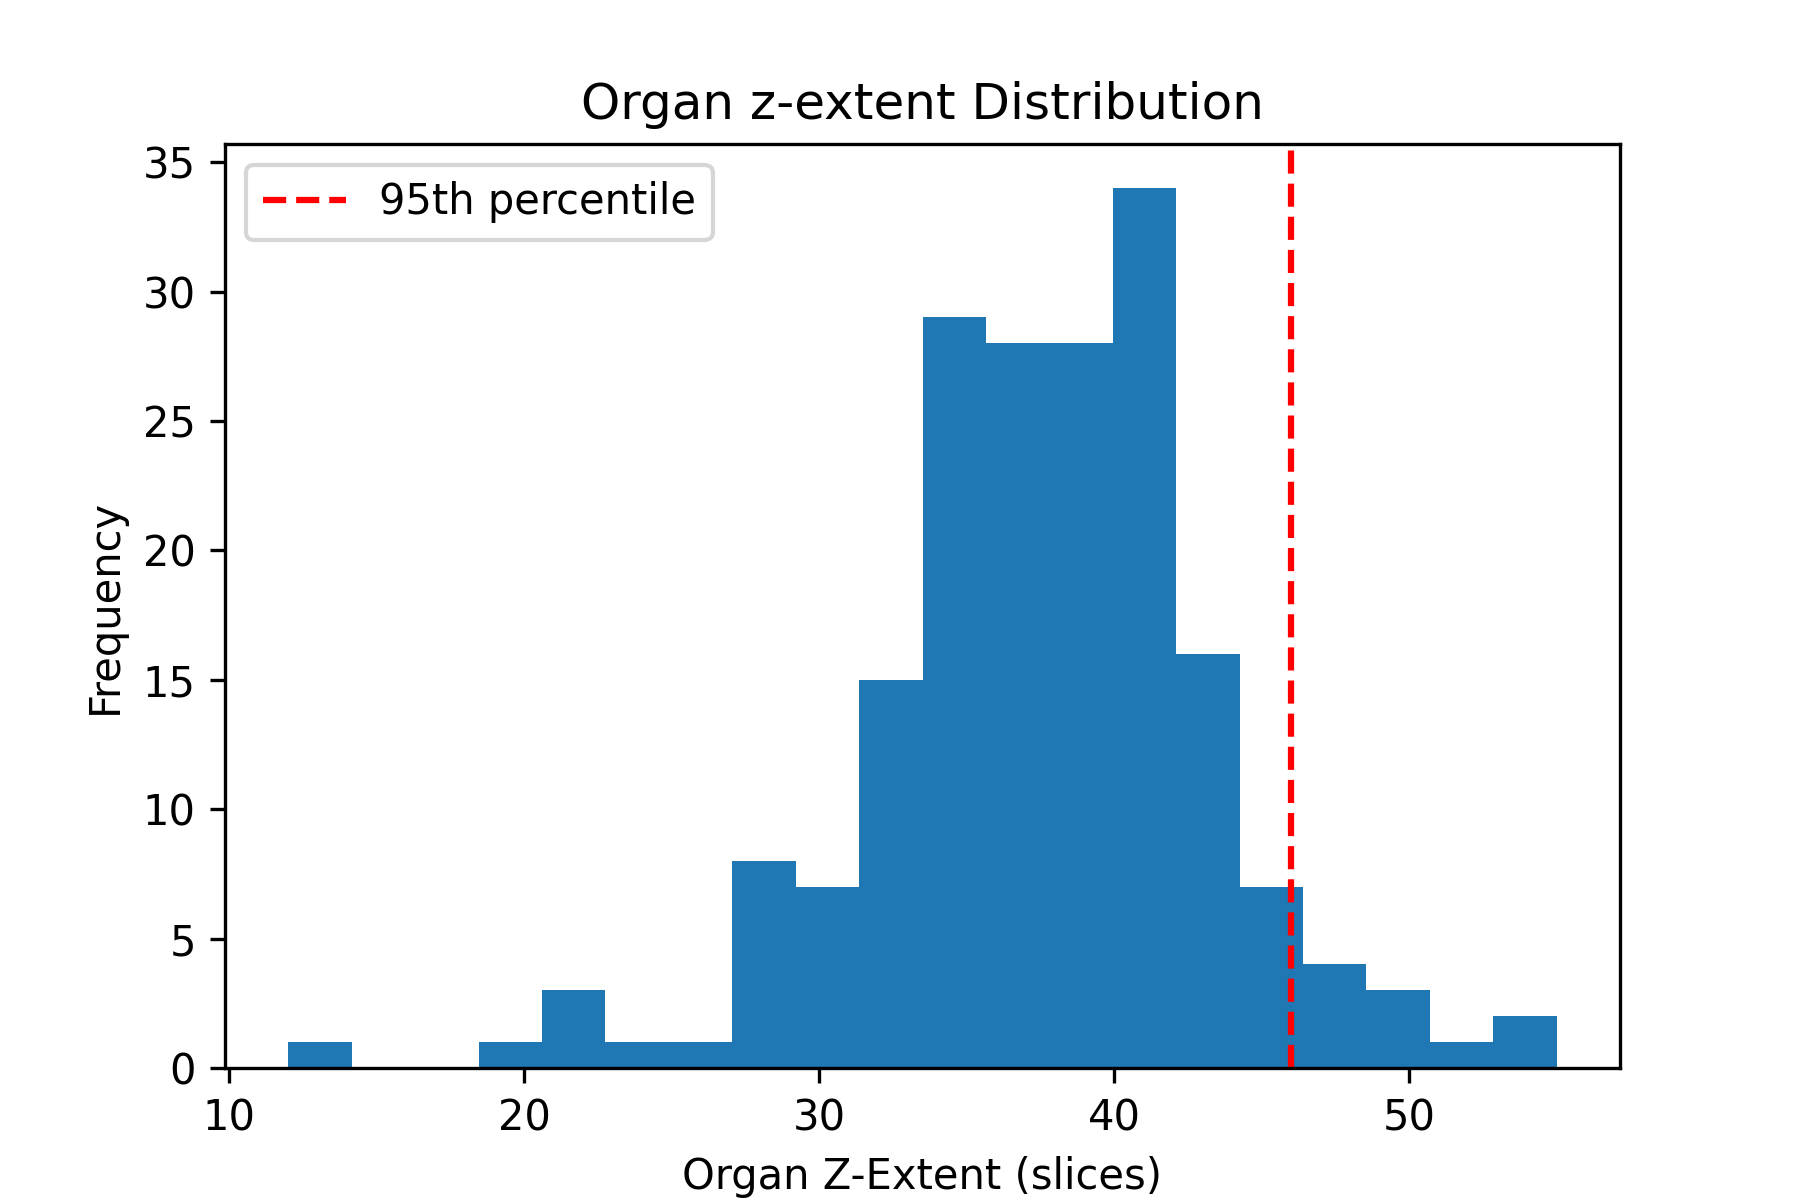

In [37]:
if image_dimensionality == "3D":
    if do_radiomics:
        print("Skipping, as radiomics features should be extracted from full images/volume.")
    else:
        mask_value = 1  # use kidney
        image_filename, mask_filename = utils.standardize_volume(nifti_dir, metadata_csv=metadata_df, metadata_csv_out=imaging_metadata_csv, image_filename=image_filename, mask_filename=mask_filename, mask_value=mask_value)
        metadata_df = pd.read_csv(imaging_metadata_csv)

        # internal to utils.standardize_volume
        visualization_dir = os.path.join(os.path.dirname(nifti_dir), "visualization")
        hist_path = os.path.join(visualization_dir, "organ_z_extent_histogram.png")
        display(Image(hist_path))

In [ ]:
if image_dimensionality == "3D":
    utils.view_nifti(os.path.join(sample_nii_dir, image_filename), z=0)

### At this point, you can pass these 3D images and masks to your training loop, or you can perform radiomics feature extraction with pyradiomics.

## 2D

In [ ]:
if image_dimensionality == "2D":
    mask_value = 2 if tumor_mask_filename else 1  # use tumor if available, otherwise use organs
    image_filename, mask_filename = utils.choose_slice_with_most_tumor(nifti_dir, metadata_csv=metadata_df, metadata_csv_out=imaging_metadata_csv, image_filename=image_filename, mask_filename=mask_filename, tumor_mask_value=mask_value)
    metadata_df = pd.read_csv(imaging_metadata_csv)

In [ ]:
if image_dimensionality == "2D":
    utils.view_nifti(os.path.join(sample_nii_dir, image_filename), z=0, overlay_mask=os.path.join(sample_nii_dir, mask_filename) if mask_filename else None)

### At this point, you can pass these 2D images and masks to your training loop, or you can perform radiomics feature extraction with pyradiomics.

# Radiomic feature extraction

In [ ]:
print(f"Final image filename: {image_filename}, Final mask filename: {mask_filename}")

In [ ]:
if do_radiomics:
    pyradiomics_param_file = os.path.join(data_dir, "pyradiomics_param.yaml")
    with open(pyradiomics_param_file, "w") as f:
        yaml.dump(pyradiomics_param, f, sort_keys=False, default_flow_style=False)

    pyradiomics_input_csv_path = os.path.join(data_dir, f"metadata_{image_dimensionality}_preradiomics.csv")
    utils.prepare_csv_for_pyradiomics(nifti_dir, output_csv_path=pyradiomics_input_csv_path, metadata_df=metadata_df, imaging_file_name=image_filename, mask_file_name=mask_filename)

    output_csv_path = os.path.join(data_dir, f"metadata_{image_dimensionality}_radiomics.csv")
    utils.perform_radiomics_pipeline(pyradiomics_input_csv_path, output_csv_path=output_csv_path, label="1,2", param=pyradiomics_param_file)

    radiomics_df = pd.read_csv(output_csv_path)
    radiomics_df.head()

### At this point, you can pass these radiomic features to your training loop, or you can perform feature selection and dimensionality reduction before training.

# Save sample images for the manuscript

In [ ]:
# import os
# from IPython.display import Image, display
# from tcga_radiogenomics import utils
# base_directory = os.path.dirname(os.path.abspath(""))
# using_usc_data = True
# data_dir = "/mnt/gpussd2/jrich/data/radiogenomics/tcga-kirc/imaging"

caseid = "TCGA-B0-5099"
z = 8
z_resampled = 20
z_standardized = 24
out_dir = os.path.join(base_directory, "output", "visualizations", caseid)

if using_usc_data:
    image_base_name = "0502_VENOUS"
    data_dir_case = os.path.join(data_dir, "nifti_usc", caseid)
else:
    image_base_name = "imaging"
    data_dir_case = os.path.join(data_dir, "nifti", caseid)

utils.view_nifti(os.path.join(data_dir_case, f"{image_base_name}.nii{'.gz' if not using_usc_data else ''}"), z=z, title=None, out_path=True, _out_dir=out_dir)
utils.view_nifti(os.path.join(data_dir_case, f"{image_base_name}_oriented.nii.gz"), z=z, title=None, out_path=True, _out_dir=out_dir)
utils.view_nifti(os.path.join(data_dir_case, f"{image_base_name}_oriented.nii.gz"), z=z, title=None, overlay_mask = os.path.join(data_dir_case, "segmentation.nii.gz"), out_path=True, _out_dir=out_dir)
utils.view_nifti(os.path.join(data_dir_case, f"{image_base_name}_oriented_clipped.nii.gz"), z=z, title=None, overlay_mask = os.path.join(data_dir_case, "segmentation.nii.gz"), out_path=True, _out_dir=out_dir)
utils.view_nifti(os.path.join(data_dir_case, f"{image_base_name}_oriented_clipped_resampled.nii.gz"), z=z_resampled, title=None, overlay_mask = os.path.join(data_dir_case, "segmentation_resampled.nii.gz"), out_path=True, _out_dir=out_dir)
utils.view_nifti(os.path.join(data_dir_case, f"{image_base_name}_oriented_clipped_resampled_normalized.nii.gz"), z=z_resampled, title=None, overlay_mask = os.path.join(data_dir_case, "segmentation_resampled.nii.gz"), out_path=True, _out_dir=out_dir)
utils.view_nifti(os.path.join(data_dir_case, "image_standardized.nii.gz"), z=z_standardized, title=None, overlay_mask = os.path.join(data_dir_case, "segmentation_standardized.nii.gz"), out_path=True, _out_dir=out_dir)

# display(Image(filename=os.path.join(data_dir_case, "totalsegmentator", "visualization", f"{caseid}_slice{z:03d}_K.png")))
# utils.view_nifti(os.path.join(data_dir_case, "segmentation.nii.gz"), z=z, title=None)
# utils.view_nifti(os.path.join(data_dir_case, "segmentation_resampled.nii.gz"), z=z_resampled, title=None)
# utils.view_nifti(os.path.join(data_dir_case, "segmentation_standardized.nii.gz"), z=z_resampled, title=None)

# Package versions

In [ ]:
!pip list